$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.10

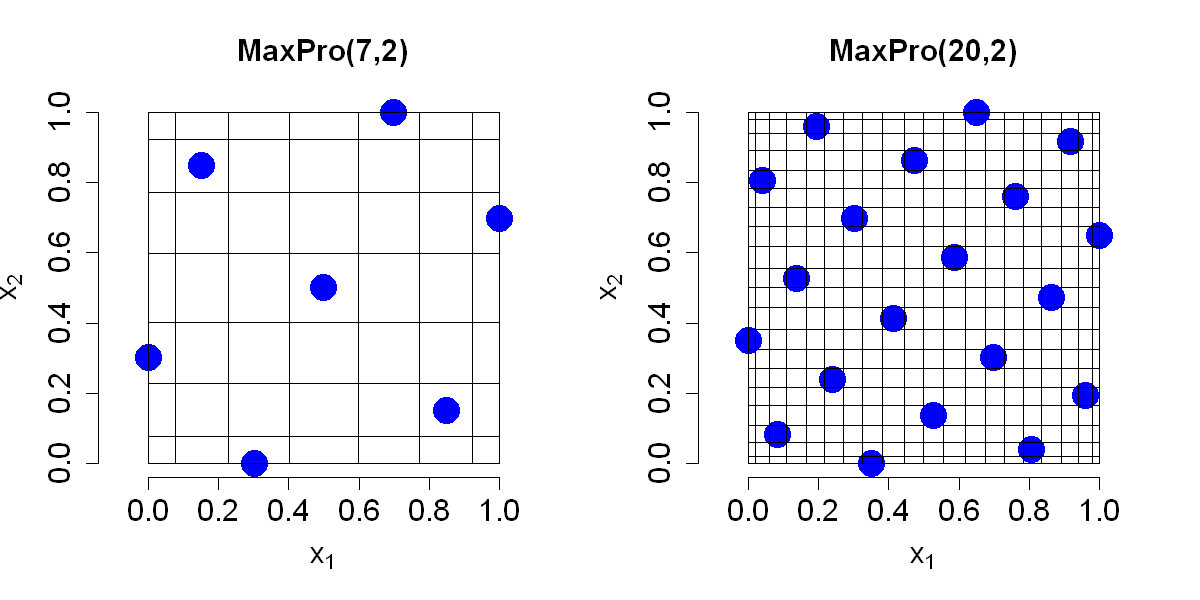

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

约瑟夫等人(2015)提出采用基于梯度的优化方法构造最大投影设计,式 (4.23) 目标函数的梯度表达式为 $$\frac{\partial}{\partial x_{rs}}\left(\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\right)=4\sum_{i\ne r}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\frac{1}{(x_{is}-x_{rs})}.$$ 但该目标函数存在大量局部最优解,想要找到全局最优通常需要设置大量随机初始点.为避免多次随机初始化,他们借鉴莫里斯与米切尔(1995)的思路,先通过模拟退火算法搜寻最大投影拉丁超立方设计,再执行梯度优化.R 语言程序包 `MaxPro` 实现了该算法(巴,约瑟夫,2018).`SFDesign` 程序包(王,约瑟夫,2025c)采用相近策略,并在模拟退火阶段之后追加一轮确定性优化,能够进一步提升设计效果.图 4.10 展示了 $p=2$,$n=7$ 与 $n=20$ 对应的最大投影设计.可以观察到,这类设计具备优良的空间填充特性且满足拉丁超立方结构;但各坐标轴上的采样点并不像标准拉丁超立方设计那样等间距分布.采样点会向区域边界偏移,不过偏移程度低于图 4.9 中经过切比雪夫变换的设计.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建画布宽 10 英寸,高 5 英寸.将画布分为 1x2.设置种子为 `10`.使用 `MaxPro` 包中的 `MaxProLHD` 函数生成一个随机的 `2` 维 `7` 点拉丁超立方设计,取出其中的 `Design` 列,再使用 `MaxPro` 包中的 `MaxPro` 函数执行完整的 MaxPro 优化流程,取出其中的 `Design` 列作为最终的设计点,令其为 `D`.作设计点矩阵图,其中点的类型为实心圆点,大小为 `3`,无边框,颜色为蓝色,$x$,$y$ 轴范围为 `[0,1]`,$x$,$y$ 轴标签分别为 `expression(x[1])`,`expression(x[2])`,轴标签,轴刻度的大小均为 `1.5`,标题为 `"MaxPro(7,2)"`,标题大小为 `1.5`,纵横比为 `1`.叠加网格,将 `D` 的行坐标排序,令其为 `d1`,计算 $$\left\{0,\frac{x_{1}+x_{2}}{2},\dots,\frac{x_{n-1}+x_{n}}{2},1\right\},$$ 令其为 `l1`.将 `D` 的列坐标排序,令其为 `d2`,计算 $$\left\{0,\frac{y_{1}+y_{2}}{2},\dots,\frac{y_{n-1}+y_{n}}{2},1\right\},$$ 令其为 `l2`.绘制竖线和横线.

```r
options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))
p=2;n=7
set.seed(10)
library(MaxPro)
D=MaxPro(MaxProLHD(n,p)$Design)$Design
plot(D,pch=16,cex=3,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=1.5,cex.axis=1.5,main="MaxPro(7,2)",cex.main=1.5,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
  segments(l1[i],0,l1[i],1)
  segments(0,l2[i],1,l2[i])
}
```

设置种子为 `10`.使用 `SFDesign` 包中的 `maxproLHD` 函数生成一个随机的 `2` 维 `7` 点拉丁超立方设计,取出其中的 `design` 列,再使用 `SFDesign` 包中的 `maxpro.optim` 函数执行完整的 MaxPro 优化流程,取出其中的 `design` 列作为最终的设计点,令其为 `D`.余同上,只是图像标题变为 `"MaxPro(20,2)"`.将画布还原回 1x1.

```r
set.seed(10)
library(SFDesign)
p=2;n=20
D=maxpro.optim(maxproLHD(n,p)$design)$design
plot(D,pch=16,cex=3,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=1.5,cex.axis=1.5,main="MaxPro(20,2)",cex.main=1.5,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
  segments(l1[i],0,l1[i],1)
  segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

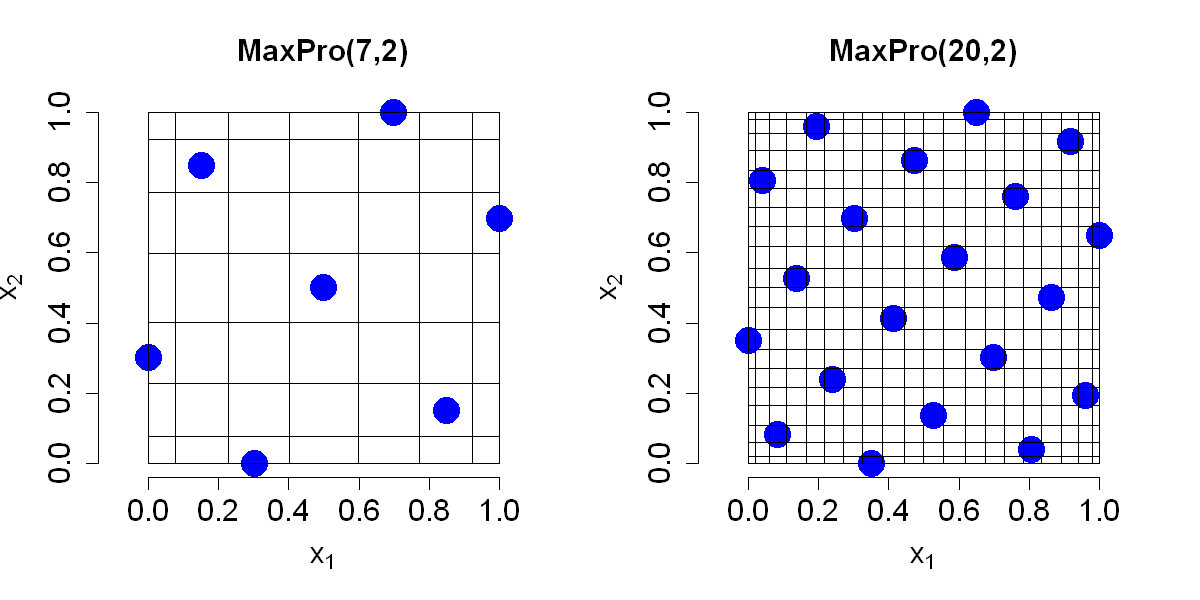

In [2]:
# 图 4.10

options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))
p=2;n=7
set.seed(10)
library(MaxPro)
D=MaxPro(MaxProLHD(n,p)$Design)$Design
plot(D,pch=16,cex=3,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=1.5,cex.axis=1.5,main="MaxPro(7,2)",cex.main=1.5,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
  segments(l1[i],0,l1[i],1)
  segments(0,l2[i],1,l2[i])
}

set.seed(10)
library(SFDesign)
p=2;n=20
D=maxpro.optim(maxproLHD(n,p)$design)$design
plot(D,pch=16,cex=3,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=1.5,cex.axis=1.5,main="MaxPro(20,2)",cex.main=1.5,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
  segments(l1[i],0,l1[i],1)
  segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$